In [ ]:
# =========================
# Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

Found 30 audio files.
Saved per-file CSV to: /content/drive/MyDrive/MusicGen_Project/Data/Spectral_Results2/spectral_analysis_results_Apollo.csv
                           file     sr  duration_sec  spectral_centroid_mean  \
0  ambient_01_apollo_output.wav  32000          5.06              470.060258   
1  ambient_02_apollo_output.wav  32000          5.06              128.112700   
2  ambient_03_apollo_output.wav  32000          5.06              764.162437   
3  ambient_04_apollo_output.wav  32000          5.06              338.155820   
4  ambient_05_apollo_output.wav  32000          5.06              439.639007   

   spectral_centroid_std  spectral_bandwidth_mean  spectral_bandwidth_std  \
0              83.719027               545.888440              124.538348   
1             142.830524               408.619994              275.688811   
2             123.975014               793.399220              172.011998   
3              74.266733               413.776963              182

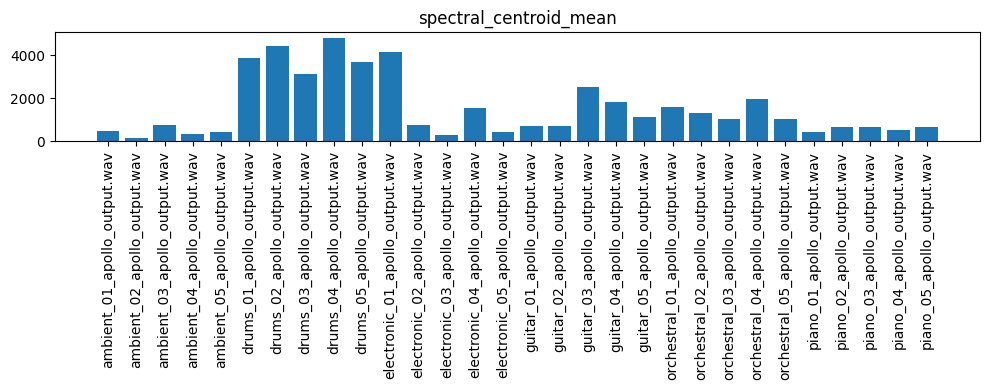

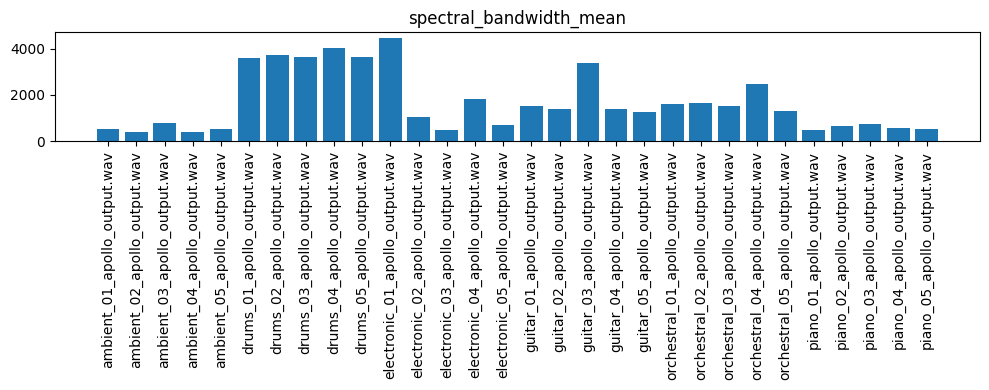

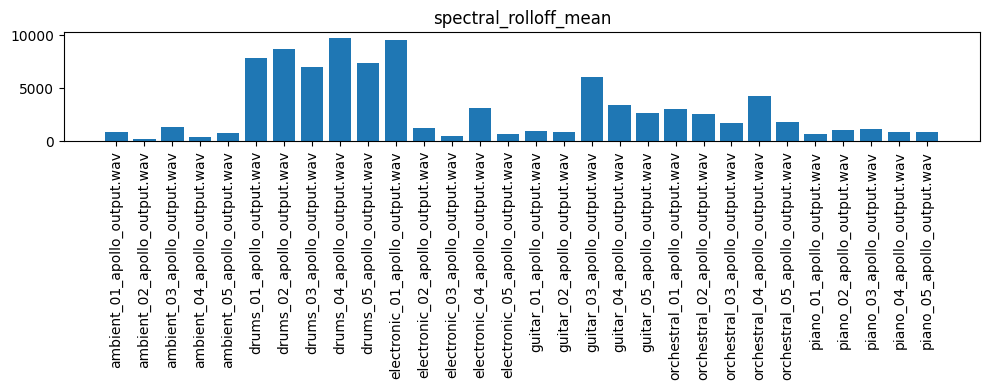

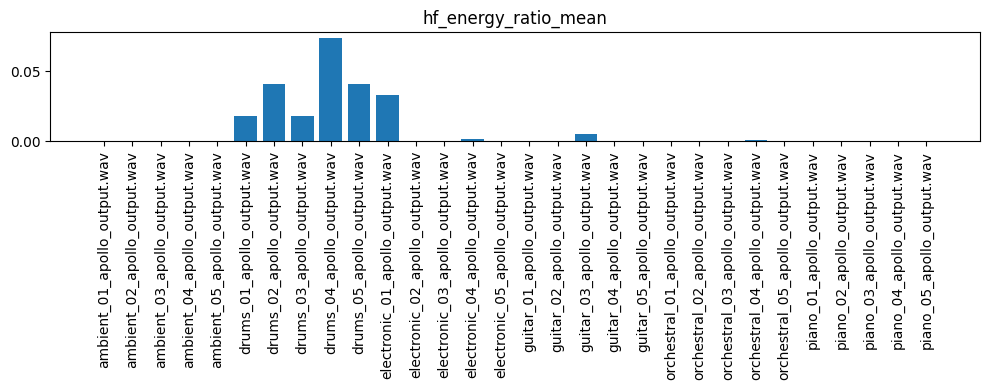

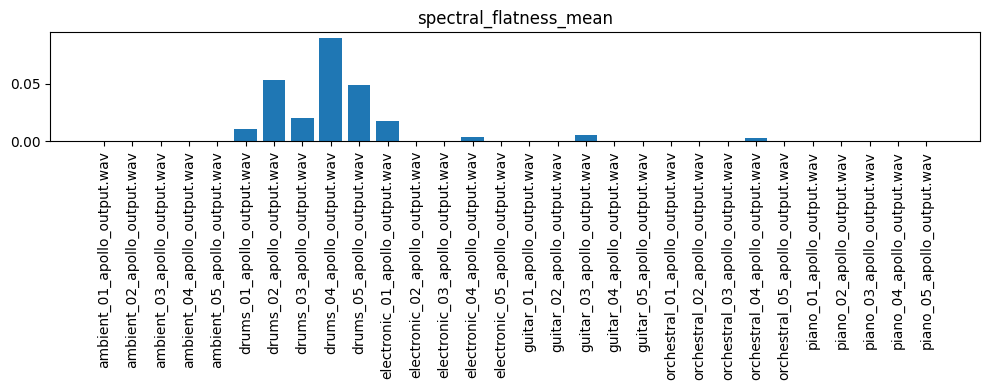

In [ ]:
# =========================
# Spectral analysis for a folder of audio files
# =========================

# -------------------------
# 1) Set my folder path
# -------------------------
input_dir = "/content/drive/MyDrive/MusicGen_Project/Data/Apollo_Output_From_raw_To_96k"
output_csv = "/content/drive/MyDrive/MusicGen_Project/Data/Spectral_Results2/spectral_analysis_results_Apollo.csv"
summary_csv = "/content/drive/MyDrive/MusicGen_Project/Data/Spectral_Results2/spectral_analysis_summary_Apollo.csv"

# -------------------------
# 2) Parameters
# -------------------------
TARGET_SR = 32000
N_FFT = 2048
HOP_LENGTH = 512
ROLLOFF_PERCENT = 0.85
HF_THRESHOLD = 8000

# -------------------------
# 3) Helper function
# -------------------------
def compute_spectral_features(file_path,
                              target_sr=32000,
                              n_fft=2048,
                              hop_length=512,
                              roll_percent=0.85,
                              hf_threshold=8000):
    # Load audio as mono
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Safety check
    if len(y) < n_fft:
        return None

    # Magnitude spectrogram
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    # Standard spectral features
    centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr, roll_percent=roll_percent)[0]
    flatness = librosa.feature.spectral_flatness(S=S)[0]

    # High-frequency energy ratio (> hf_threshold)
    power_S = S**2
    hf_mask = freqs > hf_threshold
    total_energy_per_frame = np.sum(power_S, axis=0) + 1e-12
    hf_energy_per_frame = np.sum(power_S[hf_mask, :], axis=0)
    hf_energy_ratio = hf_energy_per_frame / total_energy_per_frame

    features = {
        "file": os.path.basename(file_path),
        "sr": sr,
        "duration_sec": len(y) / sr,

        "spectral_centroid_mean": np.mean(centroid),
        "spectral_centroid_std": np.std(centroid),

        "spectral_bandwidth_mean": np.mean(bandwidth),
        "spectral_bandwidth_std": np.std(bandwidth),

        "spectral_rolloff_mean": np.mean(rolloff),
        "spectral_rolloff_std": np.std(rolloff),

        "spectral_flatness_mean": np.mean(flatness),
        "spectral_flatness_std": np.std(flatness),

        "hf_energy_ratio_mean": np.mean(hf_energy_ratio),
        "hf_energy_ratio_std": np.std(hf_energy_ratio),
    }

    return features

# -------------------------
# 4) Collect files
# -------------------------
audio_exts = (".wav",)
audio_files = [
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.lower().endswith(audio_exts)
]

audio_files = sorted(audio_files)

print(f"Found {len(audio_files)} audio files.")

# -------------------------
# 5) Run analysis
# -------------------------
results = []

for file_path in audio_files:
    try:
        feats = compute_spectral_features(
            file_path,
            target_sr=TARGET_SR,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            roll_percent=ROLLOFF_PERCENT,
            hf_threshold=HF_THRESHOLD
        )
        if feats is not None:
            results.append(feats)
        else:
            print(f"Skipped (too short): {os.path.basename(file_path)}")
    except Exception as e:
        print(f"Error with {os.path.basename(file_path)}: {e}")

df = pd.DataFrame(results)

# Save per-file results
df.to_csv(output_csv, index=False)
print(f"Saved per-file CSV to: {output_csv}")

# Show table
print(df.head())

# -------------------------
# 6) Dataset-level summary
# -------------------------
if len(df) > 0:
    summary = df.drop(columns=["file"]).mean(numeric_only=True)

    # Convert Series to one-row DataFrame
    summary_df = summary.to_frame().T
    summary_df.insert(0, "folder_name", os.path.basename(input_dir))
    summary_df.insert(1, "num_files", len(df))

    # Save summary CSV
    summary_df.to_csv(summary_csv, index=False)

    print("\nAverage over all files:")
    print(summary_df.T)

    print(f"\nSaved summary CSV to: {summary_csv}")

# -------------------------
# 7) Simple comparison plots
# -------------------------
if len(df) > 0:
    features_to_plot = [
        "spectral_centroid_mean",
        "spectral_bandwidth_mean",
        "spectral_rolloff_mean",
        "hf_energy_ratio_mean",
        "spectral_flatness_mean"
    ]

    for feat in features_to_plot:
        plt.figure(figsize=(10, 4))
        plt.bar(df["file"], df[feat])
        plt.xticks(rotation=90)
        plt.title(feat)
        plt.tight_layout()
        plt.show()